In [2]:
import numpy as np
import matplotlib.pyplot as plt

from model_utils import load_model, load_sparse_model, eval_model
from baselines import least_squares_baseline, lasso_baseline

100%|████████████████████████████████████████████████████████████████████████████████████| 6400/6400 [00:12<00:00, 521.61it/s]


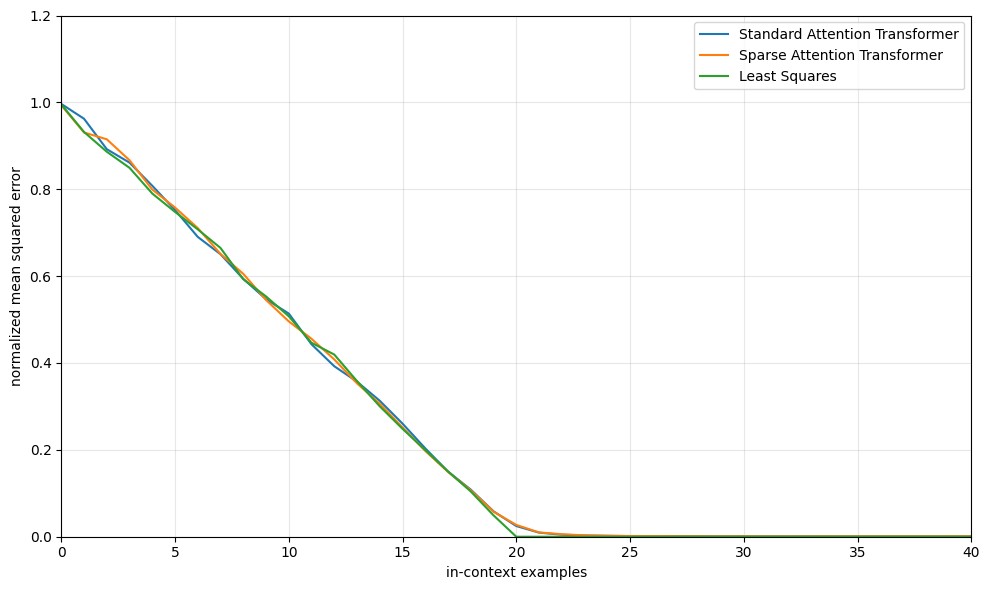

In [ ]:
model = load_model("models/dense_attention/underparameterized_linear_regression/state.pt")
sparse_model = load_sparse_model("models/sparse_attention/underparameterized_linear_regression/state.pt")

model_mses = eval_model(
    model,
    n_points = 41,
    n_dims = 20,
    num_batches = 100,
    batch_size = 64,
    sparsity = None
)

sparse_model_mses = eval_model(
    sparse_model,
    n_points = 41,
    n_dims = 20,
    num_batches = 100,
    batch_size = 64, 
    sparsity = None
)

lstsq_mses = least_squares_baseline(
    samples = 64 * 100,
    n_points = 41,
    n_dims = 20,
)

plt.figure(figsize = (10, 6))
plt.plot(np.arange(len(model_mses)), model_mses, label = "Standard Attention Transformer")
plt.plot(np.arange(len(sparse_model_mses)), sparse_model_mses, label = "Sparse Attention Transformer")
plt.plot(np.arange(len(lstsq_mses)), lstsq_mses, label = "Least Squares")
plt.xlabel("in-context examples")
plt.ylabel("normalized mean squared error")
plt.ylim(0.0, 1.2)
plt.xlim(0, 40)
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

100%|███████████████████████████████████████████████████████████████████████████████████| 6400/6400 [00:02<00:00, 2579.44it/s]


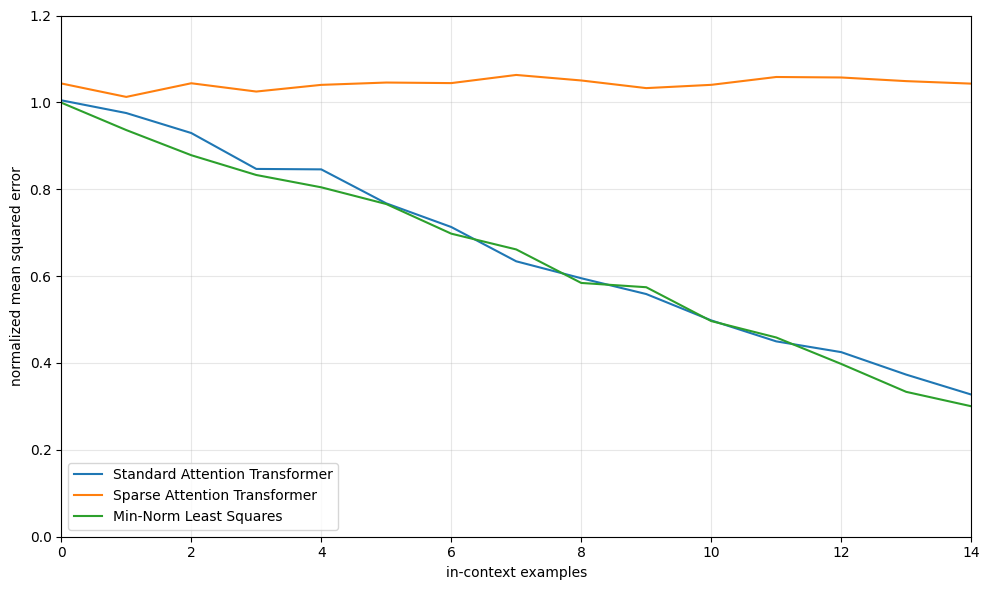

In [ ]:
model = load_model("models/dense_attention/overparameterized_linear_regression/state.pt")
sparse_model = load_model("models/sparse_attention/overparameterized_linear_regression/state.pt")

model_mses = eval_model(
    model,
    n_points = 15,
    n_dims = 20,
    num_batches = 100,
    batch_size = 64,
    sparsity = None
)

sparse_model_mses = eval_model(
    sparse_model,
    n_points = 15,
    n_dims = 20,
    num_batches = 100,
    batch_size = 64,
    sparsity = None
)

lstsq_mses = least_squares_baseline(
    samples = 64 * 100,
    n_points = 15,
    n_dims = 20
)

plt.figure(figsize = (10, 6))
plt.plot(np.arange(len(model_mses)), model_mses, label = "Standard Attention Transformer")
plt.plot(np.arange(len(sparse_model_mses)), sparse_model_mses, label = "Sparse Attention Transformer")
plt.plot(np.arange(len(lstsq_mses)), lstsq_mses, label = "Min-Norm Least Squares")
plt.xlabel("in-context examples")
plt.ylabel("normalized mean squared error")
plt.ylim(0.0, 1.2)
plt.xlim(0, 14)
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

100%|████████████████████████████████████████████████████████████████████████████████████| 6400/6400 [00:26<00:00, 244.87it/s]


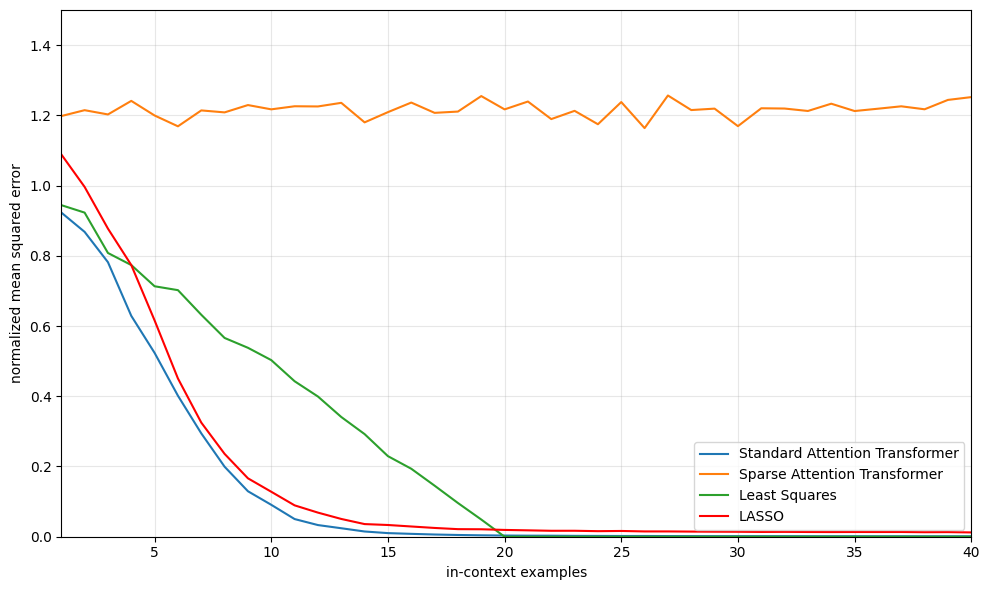

In [ ]:
model = load_model("models/dense_attention/sparse_linear_regression/state.pt")
sparse_model = load_model("models/sparse_attention/sparse_linear_regression/state.pt")

model_mses = eval_model(
    model,
    n_points = 41,
    n_dims = 20,
    num_batches = 100,
    batch_size = 64,
    sparsity = 3
)

sparse_model_mses = eval_model(
    sparse_model,
    n_points = 41,
    n_dims = 20,
    num_batches = 100,
    batch_size = 64,
    sparsity = 3
)

lstsq_mses = least_squares_baseline(
    samples = 64 * 100,
    n_points = 41,
    n_dims = 20,
    sparsity = 3
)

lasso_mses = lasso_baseline(
    samples = 64 * 100,
    n_points = 41,
    n_dims = 20,
    sparsity = 3
)

plt.figure(figsize = (10, 6))
plt.plot(np.arange(1, len(model_mses)), model_mses[1:], label = "Standard Attention Transformer")
plt.plot(np.arange(1, len(sparse_model_mses)), sparse_model_mses[1:], label = "Sparse Attention Transformer")
plt.plot(np.arange(1, len(lstsq_mses)), lstsq_mses[1:], label = "Least Squares")
plt.plot(np.arange(1, len(lasso_mses) + 1), lasso_mses, label = "LASSO", color = "red")
plt.xlabel("in-context examples")
plt.ylabel("normalized mean squared error")
plt.ylim(0.0, 1.5)
plt.xlim(1, 40)
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()